In [1]:
base_dir = "/home/shaeo/cadd_training/20251011_ChemProp"

In [2]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

## データのダウンロード

In [3]:
import os
import pandas as pd
from urllib.request import urlretrieve

In [4]:
# 設定
chemprop_dir = "/home/shaeo/opt/chemprop"
model_dir = chemprop_dir + "/models"
os.makedirs(model_dir, exist_ok=True)
model_path = model_dir + "/chemeleon_mp.pt"

data_dir = base_dir + "/data"
os.makedirs(data_dir, exist_ok=True)
data_path = data_dir + "/lipophilicity.csv"

In [4]:
# CheMelon
urlretrieve(
    r"https://zenodo.org/records/15460715/files/chemeleon_mp.pt",
    model_path,
)

('/home/shaeo/opt/chemprop/models/chemeleon_mp.pt',
 <http.client.HTTPMessage at 0x787b3e48e350>)

In [5]:
# データの取得
df = pd.read_csv("https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/Lipophilicity.csv")
df.rename(columns={'exp':'lipo'}, inplace=True)
df.to_csv(data_path, index=False)

## chemprop

In [5]:
from pathlib import Path
from chemprop import featurizers, nn, data, models
from lightning import pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint
import torch
import numpy as np

In [6]:
# データの設定
input_path = data_path # .csvファイルのパスを指定
num_workers = 0 # データローダーのワーカープロセス数。0の場合、メインプロセスでデータを読み込む
smiles_column = 'smiles' # SMILESが含まれるカラム名
target_columns = ['lipo'] # 標的が含まれるカラム名
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer() # グラフの特徴量

df_input = pd.read_csv(input_path)
smis = df_input.loc[:, smiles_column].values
ys = df_input.loc[:, target_columns].values
all_data = [data.MoleculeDatapoint.from_smi(smi, y) for smi, y in zip(smis, ys)]
mols = [d.mol for d in all_data]  # RDkit Mol

In [7]:
# データの分割
train_indices, val_indices, test_indices = data.make_split_indices(mols, "scaffold_balanced", (0.8, 0.1, 0.1))  # 訓練/検証/テストのインデックスを分割
train_data, val_data, test_data = data.split_data_by_indices(
    all_data, train_indices, val_indices, test_indices
)
train_dset = data.MoleculeDataset(train_data[0], featurizer)
scaler = train_dset.normalize_targets()
val_dset = data.MoleculeDataset(val_data[0], featurizer)
val_dset.normalize_targets(scaler)
test_dset = data.MoleculeDataset(test_data[0], featurizer)
train_loader = data.build_dataloader(train_dset, num_workers=num_workers)
val_loader = data.build_dataloader(val_dset, num_workers=num_workers, shuffle=False)
test_loader = data.build_dataloader(test_dset, num_workers=num_workers, shuffle=False)

The return type of make_split_indices has changed in v2.1 - see help(make_split_indices)
/home/shaeo/miniconda3/envs/chemprop/lib/python3.13/site-packages/astartes/samplers/extrapolation/scaffold.py:48: NoMatchingScaffold: No matching scaffold was found for the 5 molecules corresponding to indices {1573, 1701, 2087, 4180, 1948}
  warnings.warn(


In [8]:
# MessagePassingの設定
agg = nn.MeanAggregation()
chemeleon_mp = torch.load(model_path, weights_only=True)    # CheMelonの重みパラーメタを読み込む
mp_default = nn.BondMessagePassing(**chemeleon_mp['hyper_parameters'])
mp_non_fixed = nn.BondMessagePassing(**chemeleon_mp['hyper_parameters'])
mp_non_fixed.load_state_dict(chemeleon_mp['state_dict'])
mp_fixed = nn.BondMessagePassing(**chemeleon_mp['hyper_parameters'])
mp_fixed.load_state_dict(chemeleon_mp['state_dict'])
for param in mp_fixed.parameters():   # 訓練時のパラメータ更新を停止
    param.requires_grad = False

In [9]:
# ネットワークの設定
output_transform = nn.UnscaleTransform.from_standard_scaler(scaler)
ffn = nn.RegressionFFN(output_transform=output_transform, input_dim=mp_non_fixed.output_dim)
metric_list = [nn.metrics.RMSE(), nn.metrics.MAE(), nn.metrics.R2Score()]
mpnn_default = models.MPNN(mp_default, agg, ffn, batch_norm=False, metrics=metric_list)
mpnn_non_fixed = models.MPNN(mp_non_fixed, agg, ffn, batch_norm=False, metrics=metric_list)
mpnn_fixed = models.MPNN(mp_fixed, agg, ffn, batch_norm=False, metrics=metric_list)

In [10]:
# ネットワークの確認: 表示はどちらも同じ
#mpnn_non_fixed

In [11]:
# 学習の設定
checkpointing_default = ModelCheckpoint(
    "checkpoints/default",  # モデルの保存先
    "best-{epoch}-{val_loss:.2f}",  # モデルの名前、エポック数と検証データの損失
    "val_loss",  # ベストモデルの選択に利用する評価値 (検証データの損失)
    mode="min",  # 学習の方向 (評価値が低い方へ)
    save_last=True,  # 最新のエポックのモデルを保存
)
trainer_default = pl.Trainer(
    logger=False,
    enable_checkpointing=True, # モデルを保存するかどうか
    enable_progress_bar=True,
    accelerator="auto",
    devices=1,
    max_epochs=20, # 最大のエポック数
    callbacks=[checkpointing_default], # コールバックの指定
)

checkpointing_non_fixed = ModelCheckpoint(
    "checkpoints/non_fixed",
    "best-{epoch}-{val_loss:.2f}",
    "val_loss",
    mode="min",
    save_last=True,
)
trainer_non_fixed = pl.Trainer(
    logger=False,
    enable_checkpointing=True,
    enable_progress_bar=True,
    accelerator="auto",
    devices=1,
    max_epochs=20,
    callbacks=[checkpointing_non_fixed],
)

checkpointing_fixed = ModelCheckpoint(
    "checkpoints/fixed",
    "best-{epoch}-{val_loss:.2f}",
    "val_loss",
    mode="min",
    save_last=True,
)
trainer_fixed = pl.Trainer(
    logger=False,
    enable_checkpointing=True,
    enable_progress_bar=True,
    accelerator="auto",
    devices=1,
    max_epochs=20,
    callbacks=[checkpointing_fixed],
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [12]:
# 訓練
trainer_default.fit(mpnn_default, train_loader, val_loader)
trainer_non_fixed.fit(mpnn_non_fixed, train_loader, val_loader)
trainer_fixed.fit(mpnn_fixed, train_loader, val_loader)

You are using a CUDA device ('NVIDIA GeForce RTX 3060 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/home/shaeo/miniconda3/envs/chemprop/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory /home/shaeo/cadd_training/20251011_chemprop/checkpoints/default exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.
/home/shaeo/miniconda3/envs/chemprop/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `Dat

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/shaeo/miniconda3/envs/chemprop/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


In [13]:
# テストデータの評価値: default
results_default = trainer_default.test(dataloaders=test_loader)

/home/shaeo/miniconda3/envs/chemprop/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/checkpoint_connector.py:149: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.
Restoring states from the checkpoint path at /home/shaeo/cadd_training/20251011_chemprop/checkpoints/default/best-epoch=10-val_loss=0.35.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/shaeo/cadd_training/20251011_chemprop/checkpoints/default/best-epoch=10-val_loss=0.35.ckpt
/home/shaeo/miniconda3/envs/chemprop/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num

Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.5130333304405212     │
│          test/r2          │    0.6878525614738464     │
│         test/rmse         │     0.653925895690918     │
└───────────────────────────┴───────────────────────────┘

In [14]:
# テストデータの評価値: non_fixed
results_non_fixed = trainer_non_fixed.test(dataloaders=test_loader)

Restoring states from the checkpoint path at /home/shaeo/cadd_training/20251011_chemprop/checkpoints/non_fixed/best-epoch=6-val_loss=0.29.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/shaeo/cadd_training/20251011_chemprop/checkpoints/non_fixed/best-epoch=6-val_loss=0.29.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │     0.441207617521286     │
│          test/r2          │    0.7530056834220886     │
│         test/rmse         │    0.5816906690597534     │
└───────────────────────────┴───────────────────────────┘

In [15]:
# テストデータの評価値: fixed
results_fixed = trainer_fixed.test(dataloaders=test_loader)

Restoring states from the checkpoint path at /home/shaeo/cadd_training/20251011_chemprop/checkpoints/fixed/best-epoch=19-val_loss=0.37.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/shaeo/cadd_training/20251011_chemprop/checkpoints/fixed/best-epoch=19-val_loss=0.37.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.5074483156204224     │
│          test/r2          │    0.6968339681625366     │
│         test/rmse         │    0.6444495916366577     │
└───────────────────────────┴───────────────────────────┘

In [16]:
# テストデータの予測値算出
test_preds_default = trainer_default.predict(dataloaders=test_loader)
test_preds_non_fixed = trainer_non_fixed.predict(dataloaders=test_loader)
test_preds_fixed = trainer_fixed.predict(dataloaders=test_loader)

/home/shaeo/miniconda3/envs/chemprop/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/checkpoint_connector.py:149: `.predict(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.predict(ckpt_path='best')` to use the best model or `.predict(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.
Restoring states from the checkpoint path at /home/shaeo/cadd_training/20251011_chemprop/checkpoints/default/best-epoch=10-val_loss=0.35.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/shaeo/cadd_training/20251011_chemprop/checkpoints/default/best-epoch=10-val_loss=0.35.ckpt
/home/shaeo/miniconda3/envs/chemprop/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argum

Predicting: |          | 0/? [00:00<?, ?it/s]

Restoring states from the checkpoint path at /home/shaeo/cadd_training/20251011_chemprop/checkpoints/non_fixed/best-epoch=6-val_loss=0.29.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/shaeo/cadd_training/20251011_chemprop/checkpoints/non_fixed/best-epoch=6-val_loss=0.29.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

Restoring states from the checkpoint path at /home/shaeo/cadd_training/20251011_chemprop/checkpoints/fixed/best-epoch=19-val_loss=0.37.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/shaeo/cadd_training/20251011_chemprop/checkpoints/fixed/best-epoch=19-val_loss=0.37.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

In [17]:
# データローダーの中身を確認
#_ = next(iter(test_loader))
#print(_)

In [18]:
# テストデータを取り出す
records = []
for _, _, _, y, _, _, _ in test_loader:
    for yi in y:
        records.append({'y': yi.item()})
df_test = pd.DataFrame(records)

In [19]:
# 予測値を紐付ける
test_preds_default = np.concatenate(test_preds_default, axis=0)
df_test["y_pred_default"] = test_preds_default
test_preds_non_fixed = np.concatenate(test_preds_non_fixed, axis=0)
df_test["y_pred_non_fixed"] = test_preds_non_fixed
test_preds_fixed = np.concatenate(test_preds_fixed, axis=0)
df_test["y_pred_fixed"] = test_preds_fixed

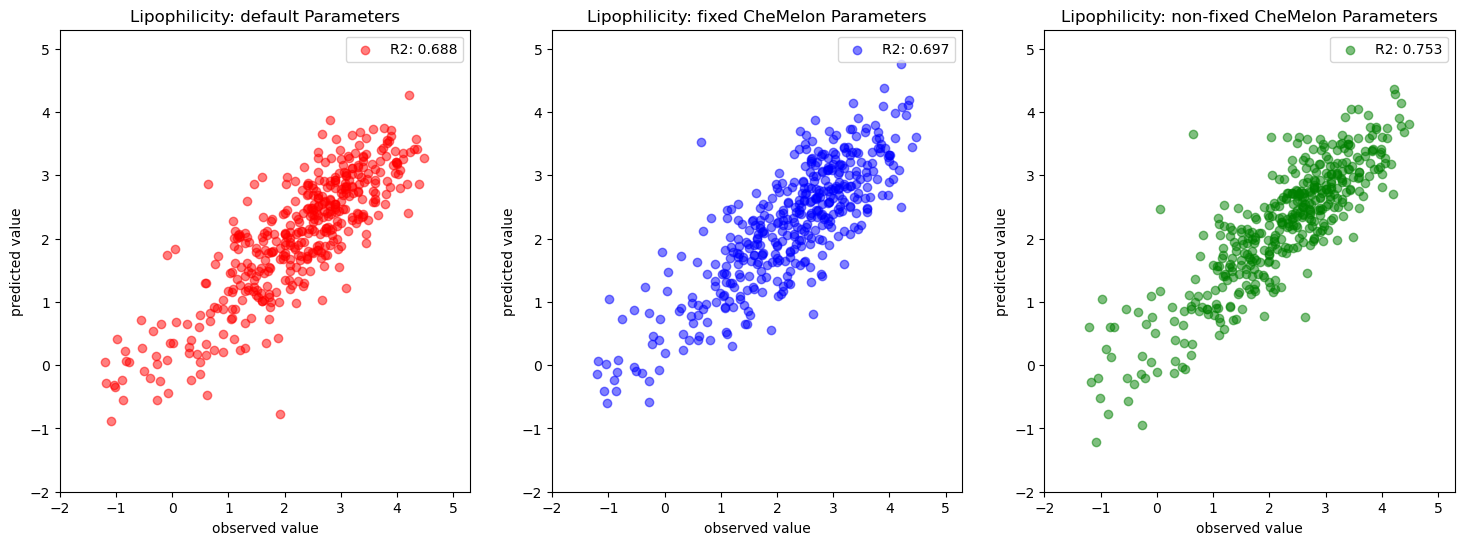

In [22]:
# プロット
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].scatter(df_test["y"], df_test["y_pred_default"], alpha=0.5, color="r", label=f"R2: {results_default[0]['test/r2']:.3}")
ax[0].set_title("Lipophilicity: default Parameters")
ax[0].set_xlabel("observed value")
ax[0].set_ylabel("predicted value")
ax[0].set_xlim(-2, 5.3)
ax[0].set_ylim(-2, 5.3)
ax[0].legend()

ax[1].scatter(df_test["y"], df_test["y_pred_fixed"], alpha=0.5, color="b", label=f"R2: {results_fixed[0]['test/r2']:.3}")
ax[1].set_title("Lipophilicity: fixed CheMelon Parameters")
ax[1].set_xlabel("observed value")
ax[1].set_ylabel("predicted value")
ax[1].set_xlim(-2, 5.3)
ax[1].set_ylim(-2, 5.3)
ax[1].legend()

ax[2].scatter(df_test["y"], df_test["y_pred_non_fixed"], alpha=0.5, color="g", label=f"R2: {results_non_fixed[0]['test/r2']:.3}")
ax[2].set_title("Lipophilicity: non-fixed CheMelon Parameters")
ax[2].set_xlabel("observed value")
ax[2].set_ylabel("predicted value")
ax[2].set_xlim(-2, 5.3)
ax[2].set_ylim(-2, 5.3)
ax[2].legend()

plt.show()